### Задача 1. PCA для виявлення шахрайства з картками 
- Мета: зменшити вимірність і знайти підозрілі транзакції. 
- Дані: Credit Card Fraud Dataset (Kaggle) 
- Кроки: 
    - Завантаж дані (creditcard.csv), де вже є PCA-компоненти V1–V28. 
    - Візьми лише кілька з них і застосуй PCA(n_components=2) для візуалізації. 
    - Побудуй графік, де шахрайські операції червоні, звичайні — сині. 
    - Поясни, чи видно в PCA-просторі відокремлення шахрайських транзакцій. 
    - Очікуваний результат: 
        - Студенти побачать, що PCA може частково відділити “аномалії”. 
        - Обговорення важливості масштабування і балансу класів.

Дані завантажено та масштабовано.
Розмірність X перед PCA: (284807, 30)
Розмірність X після PCA: (284807, 2)
PCA завершено.


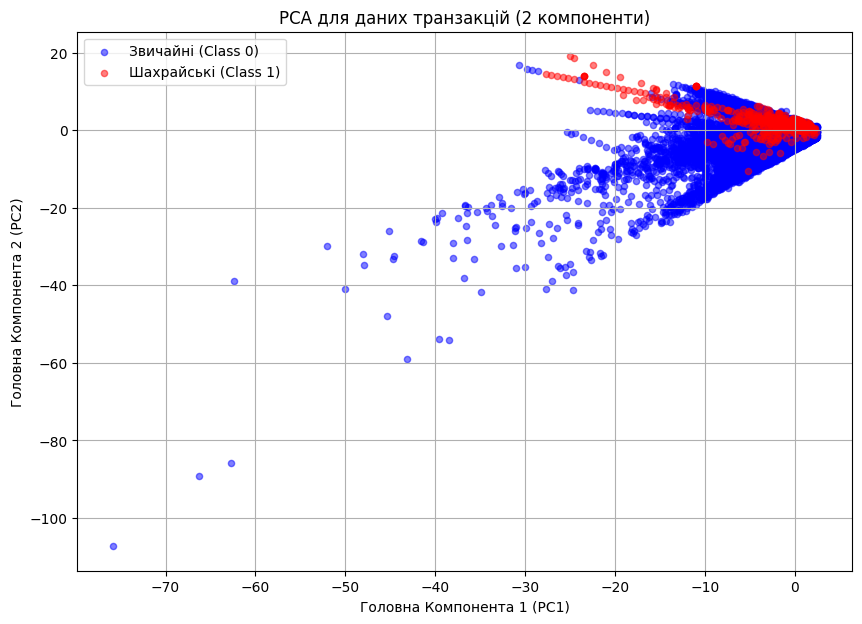

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Завантажимо дані
file_path = 'DataSet/creditcard.csv'
try:
    data = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Помилка: Файл не знайдено за шляхом {file_path}")
    print("Переконайтеся, що папка 'DataSet' знаходиться поруч з вашим блокнотом.")

# 2. Масштабування 'Amount' і 'Time'
# V1-V28 вже масштабовані
scaler = StandardScaler()

# Створимо копії, щоб не змінювати оригінальний data
data_scaled = data.copy()
data_scaled['scaled_Amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
data_scaled['scaled_Time'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))

# 3. Видалимо старі стовпці 'Time' та 'Amount' і стовпець 'Class' (це наша ціль)
# 'Class' ми збережемо окремо
y = data_scaled['Class']
X = data_scaled.drop(['Time', 'Amount', 'Class'], axis=1)

print("Дані завантажено та масштабовано.")
print(f"Розмірність X перед PCA: {X.shape}")

#------------------------------------------------------
# 4. Застосуємо PCA
# Ми хочемо отримати 2 компоненти для 2D-графіка
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"Розмірність X після PCA: {X_pca.shape}")

# 5. Створимо зручний DataFrame для візуалізації
# Додаємо наші 2 нові компоненти і стовпець 'Class'
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Class'] = y

print("PCA завершено.")
#------------------------------------------------------

# 6. Візуалізація
plt.figure(figsize=(10, 7))

# Визначимо кольори
colors = {0: 'blue', 1: 'red'}
labels = {0: 'Звичайні (Class 0)', 1: 'Шахрайські (Class 1)'}

# Малюємо точки для кожного класу
for class_value in [0, 1]:
    subset = df_pca[df_pca['Class'] == class_value]
    plt.scatter(subset['PC1'], 
                subset['PC2'], 
                c=colors[class_value], 
                label=labels[class_value], 
                alpha=0.5,  # Прозорість, щоб бачити скупчення
                s=20)       # Малий розмір точок

plt.title('PCA для даних транзакцій (2 компоненти)')
plt.xlabel('Головна Компонента 1 (PC1)')
plt.ylabel('Головна Компонента 2 (PC2)')
plt.legend()
plt.grid(True)
plt.show()


### Задача 2. PCA у біоінформатиці (Gene Expression Data) 
- Мета: зменшити вимірність набору з 1000+ генів для класифікації типу раку. 
- Дані: Gene Expression Cancer RNA-Seq Data (Kaggle) 
- Кроки: Візьми матрицю (рядки — зразки, стовпці — експресія генів). 
- Масштабуй дані, застосуй PCA(n_components=10). 
- Поясни, скільки дисперсії збереглося. 
- Використай PCA-компоненти для навчання SVM або RandomForestClassifier. 
- Порівняй точність із моделлю без PCA. 
- Очікуваний результат: 
    - Модель після PCA легша, менш схильна до перенавчання. 
    - Розуміння користі PCA в біомедичних задачах.

In [6]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Шляхи до файлів 
data_path = 'DataSet/Gene Expression Cancer RNA-Seq Data/data.csv'
labels_path = 'DataSet/Gene Expression Cancer RNA-Seq Data/labels.csv'

# 2. Завантаимо дані
# index_col=0 каже pandas використовувати перший стовпець (Sample ID) як індекс
try:
    data = pd.read_csv(data_path, index_col=0)
    labels = pd.read_csv(labels_path, index_col=0)
except FileNotFoundError:
    print(f"Помилка: Файли не знайдено.")
    print(f"Перевірте шлях: {data_path}")

# X - це наші ознаки (гени), y - наша ціль (тип раку)
X = data
y = labels['Class']

print(f"Дані завантажено.")
print(f"Форма матриці генів (X): {X.shape}") # (Зразки, Гени)
print(f"Форма міток (y): {y.shape}")
print(f"У нас {X.shape[1]} генів (ознак) і {X.shape[0]} зразків.")


# 3. Масштабування
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Дані масштабовано (StandardScaler).")


# Розділимо дані на тренувальні та тестові
# random_state=42 гарантує, що ми отримаємо однаковий поділ щоразу
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# --- Навчання на повних даних ---
print("\n--- Експеримент 1: Навчання на всіх 20,000+ генах ---")
model_full = RandomForestClassifier(n_estimators=100, random_state=42)

start_time = time.time()
model_full.fit(X_train, y_train)
end_time = time.time()

# Оцінка
y_pred_full = model_full.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred_full)
time_full = end_time - start_time

print(f"Точність (Повні дані): {accuracy_full * 100:.2f}%")
print(f"Час навчання: {time_full:.4f} секунд")


# 4. Застосування PCA
# Візьмемо 10 компонентів
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled) # Застосуємо до масштабованих даних

print(f"\nДані стиснуто з {X_scaled.shape[1]} до {X_pca.shape[1]} компонент.")

# 5. Скільки дисперсії збереглося?
explained_variance = pca.explained_variance_ratio_.sum()
print(f"10 головних компонент пояснюють {explained_variance * 100:.2f}% дисперсії.")

# --- Навчання на PCA-даних ---
print("\n--- Експеримент 2: Навчання на 10 PCA-компонентах ---")
# Розділимо дані, але тепер X_pca
X_pca_train, X_pca_test, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)

model_pca = RandomForestClassifier(n_estimators=100, random_state=42)

start_time = time.time()
model_pca.fit(X_pca_train, y_train_pca)
end_time = time.time()

# Оцінка
y_pred_pca = model_pca.predict(X_pca_test)
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)
time_pca = end_time - start_time

print(f"Точність (10 PCA-компонент): {accuracy_pca * 100:.2f}%")
print(f"Час навчання: {time_pca:.4f} секунд")




Дані завантажено.
Форма матриці генів (X): (801, 20531)
Форма міток (y): (801,)
У нас 20531 генів (ознак) і 801 зразків.
Дані масштабовано (StandardScaler).

--- Експеримент 1: Навчання на всіх 20,000+ генах ---
Точність (Повні дані): 100.00%
Час навчання: 2.8865 секунд

Дані стиснуто з 20531 до 10 компонент.
10 головних компонент пояснюють 46.59% дисперсії.

--- Експеримент 2: Навчання на 10 PCA-компонентах ---
Точність (10 PCA-компонент): 99.17%
Час навчання: 0.1835 секунд
